<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-297-Natural-Language-Processing/blob/main/FinSight_Agent_Prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FinSight Agent — Mini Prototype

A small, runnable demo of **what our team wants to build**: an autonomous research **agent** (not just a chatbot) that takes a goal, makes a plan, asks a human to approve it, collects real SEC data, analyzes it, and writes a **cited** bull/bear brief.

It borrows the core ideas from the paper *FinSight: Towards Real-World Financial Deep Research* (Jin et al.):

| Idea from the paper | Where it is in this notebook |
|---|---|
| **CAVM** — one shared "variable space" for data, tools and agents | `SharedMemory` (Step 1) |
| Agents act by **writing code** that reads/writes that memory (`save_result`) | Analysis Agent (Step 5) |
| Multi-agent split: data collection → analysis → report | Steps 4, 5, 6 |
| **Two-stage writing**: short analysis notes with IDs → full report that may only cite those IDs | Report Agent (Step 6) |
| Professor's feedback: autonomous agent + **human in the loop** | Plan approval (Step 3), proactive monitor (Step 7) |

**How to run:** put your name + email in `USER_AGENT` below (SEC requires it), then *Runtime → Run all*.
Everything works for free with no API keys. Optional keys (Finnhub news, any OpenAI-compatible LLM) unlock extra features.

> This is a teaching prototype, not investment advice. The real system replaces the simple rules here with LLM agents.

In [12]:
# ===================== CONFIG: edit these =====================
USER_AGENT = "FinSight Team meenakshi.rajpurohit@sjsu.edu"   # SEC requires a real name + email
TICKERS    = ["NVDA", "AMD"]                      # companies to research
USER_GOAL  = "Compare NVIDIA and AMD's recent revenue growth and profitability"
AUTO_APPROVE = False   # True = skip the human-approval prompt (useful for 'Run all')

# ---- Optional (leave empty = fully free mode, no keys needed) ----
FINNHUB_KEY  = ""      # free key from finnhub.io -> adds recent news + sentiment
LLM_API_KEY  = ""      # any OpenAI-compatible chat API key -> LLM writes the report
LLM_BASE_URL = ""      # your provider's base URL ending in /v1
LLM_MODEL    = ""      # a model name from your provider's docs

if "yourname" in USER_AGENT:
    print("⚠️  Please put your real name + email in USER_AGENT, or SEC may block requests.")

## Step 1 — Shared memory (the paper's CAVM idea)
Every agent reads from and writes to **one** memory. Each item has a name, a description, which agent made it, and a **source ID** (`S1`, `S2`, …) so any fact can be cited later. `describe()` is what an LLM agent would "see" at each step.

In [13]:
import re, time, datetime as dt
import requests
import pandas as pd

class SharedMemory:
    def __init__(self):
        self.vars = {}      # name -> {value, description, agent, source}
        self.sources = {}   # "S1" -> {citation, url}
        self.log = []

    def add_source(self, citation, url):
        for sid, s in self.sources.items():          # reuse ID if we already have this URL
            if s["url"] == url:
                return sid
        sid = f"S{len(self.sources) + 1}"
        self.sources[sid] = {"citation": citation, "url": url}
        return sid

    def save(self, name, value, description, agent, source=None):
        self.vars[name] = {"value": value, "description": description, "agent": agent, "source": source}
        self.log.append(f"[{agent}] saved '{name}'")

    def get(self, name):
        return self.vars[name]["value"]

    def describe(self):
        if not self.vars:
            return "(memory is empty)"
        return "\n".join(f"- {n}: {v['description']} (by {v['agent']})" for n, v in self.vars.items())

memory = SharedMemory()

def vname(ticker):                       # safe variable name, e.g. BRK.B -> BRK_B
    return re.sub(r"\W", "_", ticker.upper())

def cite(*ids):                          # "[S1][S2]" with duplicates removed
    return "".join(f"[{i}]" for i in dict.fromkeys(ids))

def fmt_usd(x):
    return f"${x/1e9:,.2f}B" if abs(x) >= 1e9 else f"${x/1e6:,.1f}M"

print("Shared memory ready.")

Shared memory ready.


## Step 2 — Tools the agents can call
* **SEC EDGAR** (free, no key): ticker → CIK, XBRL financial facts, list of recent filings.
* **Finnhub** (optional free key): recent company news.
* **Sentiment**: a tiny word-list scorer so it runs anywhere. In the real system swap in FinBERT (`ProsusAI/finbert`).
* **LLM** (optional): any OpenAI-compatible chat endpoint.

In [14]:
HEADERS = {"User-Agent": USER_AGENT}

def sec_get(url):
    r = requests.get(url, headers=HEADERS, timeout=30)
    if r.status_code != 200:
        raise RuntimeError(f"SEC returned {r.status_code} for {url}. Check USER_AGENT (name + email).")
    time.sleep(0.2)                      # stay well under SEC's 10 requests/second limit
    return r.json()

_ticker_map = None
def get_cik(ticker):
    global _ticker_map
    if _ticker_map is None:
        data = sec_get("https://www.sec.gov/files/company_tickers.json")
        _ticker_map = {row["ticker"].upper(): (row["cik_str"], row["title"]) for row in data.values()}
    return _ticker_map[ticker.upper()]   # -> (cik number, company name)

def quarterly_series(facts, tags, unit="USD"):
    # 3-month values for whichever XBRL tag has the most recent data
    # (companies use different tags for the same item, e.g. revenue).
    best = None
    for tag in tags:
        entries = facts["facts"].get("us-gaap", {}).get(tag, {}).get("units", {}).get(unit, [])
        df = pd.DataFrame(entries)
        if df.empty or "start" not in df:
            continue
        df = df.dropna(subset=["start"])
        days = (pd.to_datetime(df["end"]) - pd.to_datetime(df["start"])).dt.days
        df = df[days.between(80, 100)]                    # keep quarters, drop YTD/annual
        if df.empty:
            continue
        df = (df.sort_values("filed").drop_duplicates("end", keep="last")   # latest filing wins
                .sort_values("end").reset_index(drop=True))
        df = df.rename(columns={"val": "value"})[["start", "end", "value", "form", "filed", "accn"]]
        df["tag"] = tag
        if best is None or df["end"].iloc[-1] > best["end"].iloc[-1]:
            best = df
    return best

def recent_filings(cik, forms=("10-K", "10-Q", "8-K"), since=None):
    sub = sec_get(f"https://data.sec.gov/submissions/CIK{cik:010d}.json")
    rec = sub["filings"]["recent"]
    out = []
    for form, date, accn, doc in zip(rec["form"], rec["filingDate"], rec["accessionNumber"], rec["primaryDocument"]):
        if form in forms and (since is None or date > since):
            out.append({"form": form, "date": date,
                        "url": f"https://www.sec.gov/Archives/edgar/data/{cik}/{accn.replace('-', '')}/{doc}"})
    return out

def get_news(ticker, days=14):
    if not FINNHUB_KEY:
        return []
    today = dt.date.today()
    r = requests.get("https://finnhub.io/api/v1/company-news",
                     params={"symbol": ticker, "from": str(today - dt.timedelta(days=days)),
                             "to": str(today), "token": FINNHUB_KEY}, timeout=30)
    r.raise_for_status()
    return r.json()[:10]

POS = {"beat", "beats", "record", "growth", "surge", "strong", "raises", "upgrade", "gain", "gains", "rally", "outperform"}
NEG = {"miss", "misses", "decline", "drop", "falls", "weak", "cut", "cuts", "downgrade", "loss", "lawsuit", "probe", "slump"}
def simple_sentiment(text):
    words = re.findall(r"[a-z]+", text.lower())
    score = sum(w in POS for w in words) - sum(w in NEG for w in words)
    return "positive" if score > 0 else "negative" if score < 0 else "neutral"

def call_llm(prompt):
    if not (LLM_API_KEY and LLM_BASE_URL and LLM_MODEL):
        return None                                      # free mode: no LLM
    r = requests.post(f"{LLM_BASE_URL.rstrip('/')}/chat/completions",
                      headers={"Authorization": f"Bearer {LLM_API_KEY}"},
                      json={"model": LLM_MODEL, "temperature": 0.2,
                            "messages": [{"role": "user", "content": prompt}]},
                      timeout=120)
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

print("Tools ready.")

Tools ready.


## Step 3 — Planner + human in the loop
The agent turns the goal into a plan and **waits for a human to approve it** before doing anything. (In the full system an LLM writes this plan.)

In [15]:
plan = [f"Collect quarterly revenue, net income and diluted EPS from SEC XBRL for {t}" for t in TICKERS]
if FINNHUB_KEY:
    plan += [f"Collect last 14 days of news for {t} and score sentiment" for t in TICKERS]
plan += ["Analyze growth and margins (write short analysis notes with source IDs)",
         "Write a cited bull/bear brief and check every citation"]

print(f"GOAL: {USER_GOAL}\n\nPROPOSED PLAN:")
for i, step in enumerate(plan, 1):
    print(f"  {i}. {step}")

APPROVED = AUTO_APPROVE or input("\nApprove this plan? (y/n): ").strip().lower().startswith("y")
print("✅ Approved — agents will run." if APPROVED else "❌ Not approved — change TICKERS/USER_GOAL and re-run.")

GOAL: Compare NVIDIA and AMD's recent revenue growth and profitability

PROPOSED PLAN:
  1. Collect quarterly revenue, net income and diluted EPS from SEC XBRL for NVDA
  2. Collect quarterly revenue, net income and diluted EPS from SEC XBRL for AMD
  3. Analyze growth and margins (write short analysis notes with source IDs)
  4. Write a cited bull/bear brief and check every citation

Approve this plan? (y/n): y
✅ Approved — agents will run.


## Step 4 — Data Collection Agent
Pulls real numbers from SEC EDGAR and saves them into shared memory. Every filing used gets a source ID, so later agents can cite it.

In [16]:
assert APPROVED, "Plan was not approved."
AGENT = "DataCollectionAgent"

METRICS = {   # memory name prefix -> (XBRL tags to try, unit)
    "revenue":    (["Revenues", "RevenueFromContractWithCustomerExcludingAssessedTax", "SalesRevenueNet"], "USD"),
    "net_income": (["NetIncomeLoss"], "USD"),
    "eps":        (["EarningsPerShareDiluted"], "USD/shares"),
}

for t in TICKERS:
    cik, name = get_cik(t)
    facts = sec_get(f"https://data.sec.gov/api/xbrl/companyfacts/CIK{cik:010d}.json")
    memory.save(f"company_{vname(t)}", {"ticker": t, "cik": cik, "name": name}, f"Basic info for {t}", AGENT)

    for prefix, (tags, unit) in METRICS.items():
        df = quarterly_series(facts, tags, unit)
        if df is None:
            print(f"  {t}: no quarterly data found for {prefix}")
            continue
        df = df.tail(8).reset_index(drop=True)       # last 8 quarters is enough for the demo
        df["source"] = [memory.add_source(f"{t} {row.form} filed {row.filed} (SEC XBRL, accession {row.accn})",
                                          f"https://www.sec.gov/Archives/edgar/data/{cik}/{row.accn.replace('-', '')}/")
                        for row in df.itertuples()]
        memory.save(f"{prefix}_{vname(t)}", df, f"{t} quarterly {prefix} ({df['tag'].iloc[0]}), {len(df)} quarter(s)", AGENT)

    news = []
    for a in get_news(t):
        sid = memory.add_source(f"{a.get('source', 'News')}: {a.get('headline', '')[:70]}", a.get("url", ""))
        news.append({"headline": a.get("headline", ""), "sentiment": simple_sentiment(a.get("headline", "")), "source": sid})
    if news:
        memory.save(f"news_{vname(t)}", news, f"{len(news)} recent headlines for {t} with sentiment", AGENT)
    print(f"✓ {t} ({name}) collected")

print("\nWHAT IS IN SHARED MEMORY NOW:\n" + memory.describe())

✓ NVDA (NVIDIA CORP) collected
✓ AMD (ADVANCED MICRO DEVICES INC) collected

WHAT IS IN SHARED MEMORY NOW:
- company_NVDA: Basic info for NVDA (by DataCollectionAgent)
- revenue_NVDA: NVDA quarterly revenue (Revenues), 8 quarter(s) (by DataCollectionAgent)
- net_income_NVDA: NVDA quarterly net_income (NetIncomeLoss), 8 quarter(s) (by DataCollectionAgent)
- eps_NVDA: NVDA quarterly eps (EarningsPerShareDiluted), 8 quarter(s) (by DataCollectionAgent)
- company_AMD: Basic info for AMD (by DataCollectionAgent)
- revenue_AMD: AMD quarterly revenue (RevenueFromContractWithCustomerExcludingAssessedTax), 8 quarter(s) (by DataCollectionAgent)
- net_income_AMD: AMD quarterly net_income (NetIncomeLoss), 8 quarter(s) (by DataCollectionAgent)
- eps_AMD: AMD quarterly eps (EarningsPerShareDiluted), 8 quarter(s) (by DataCollectionAgent)


## Step 5 — Analysis Agent (acts by writing code)
This is the paper's key trick. The agent does not get a fixed menu of buttons; it **writes Python** that uses the memory variables **by name** (e.g. `revenue_NVDA`, saved by a different agent) and stores results with `save_result(...)`.

Here the code is pre-written so the demo runs without an LLM. In the full system, the LLM writes this code after reading `memory.describe()`.

In [17]:
ANALYSIS_CODE = '''
rev, ni = revenue_TICKER, net_income_TICKER
latest, prev = rev.iloc[-1], rev.iloc[-2]
notes, metrics = [], {}

# Revenue vs prior quarter (only if the two periods are back-to-back quarters)
if 80 <= (pd.Timestamp(latest.end) - pd.Timestamp(prev.end)).days <= 100:
    metrics["rev_qoq"] = (latest.value - prev.value) / prev.value * 100
    notes.append(f"Revenue for the quarter ended {latest.end} was {fmt_usd(latest.value)}, "
                 f"{metrics['rev_qoq']:+.1f}% vs the prior quarter {cite(latest.source, prev.source)}.")

# Revenue vs same quarter last year
year_ago = rev[(pd.Timestamp(latest.end) - pd.to_datetime(rev.end)).dt.days.between(350, 380)]
if len(year_ago):
    ya = year_ago.iloc[-1]
    metrics["rev_yoy"] = (latest.value - ya.value) / ya.value * 100
    notes.append(f"Year over year, revenue changed {metrics['rev_yoy']:+.1f}% "
                 f"(from {fmt_usd(ya.value)}) {cite(latest.source, ya.source)}.")

# Net margin = net income / revenue for matching quarters
m = rev.merge(ni[["end", "value", "source"]], on="end", suffixes=("", "_ni"))
if len(m):
    metrics["margin"] = m.iloc[-1].value_ni / m.iloc[-1].value * 100
    notes.append(f"Net margin for the quarter ended {m.iloc[-1].end} was {metrics['margin']:.1f}% {cite(m.iloc[-1].source, m.iloc[-1].source_ni)}.")
if len(m) >= 2 and 80 <= (pd.Timestamp(m.iloc[-1].end) - pd.Timestamp(m.iloc[-2].end)).days <= 100:
    metrics["margin_change"] = metrics["margin"] - m.iloc[-2].value_ni / m.iloc[-2].value * 100
    notes.append(f"Net margin moved {metrics['margin_change']:+.1f} percentage points vs the prior quarter {cite(m.iloc[-1].source_ni, m.iloc[-2].source_ni)}.")

save_result("notes_TICKER", notes, "Analysis notes for TICKER (facts with source IDs)")
save_result("metrics_TICKER", metrics, "Computed metrics for TICKER")
'''

def run_code_action(code_text, agent):
    def save_result(name, value, description):           # the only way code can write to memory
        memory.save(name, value, description, agent)
    namespace = {n: v["value"] for n, v in memory.vars.items()}   # every memory variable, by name
    namespace.update(pd=pd, fmt_usd=fmt_usd, cite=cite, save_result=save_result)
    exec(code_text, namespace)   # ⚠️ a real system must run LLM-written code in a sandbox

for t in TICKERS:
    if f"revenue_{vname(t)}" not in memory.vars or f"net_income_{vname(t)}" not in memory.vars:
        print(f"Skipping {t}: missing data"); continue
    run_code_action(ANALYSIS_CODE.replace("TICKER", vname(t)), "AnalysisAgent")
    news = memory.vars.get(f"news_{vname(t)}", {}).get("value", [])
    if news:
        pos = sum(n["sentiment"] == "positive" for n in news); neg = sum(n["sentiment"] == "negative" for n in news)
        memory.get(f"metrics_{vname(t)}")["news_balance"] = pos - neg
        memory.get(f"notes_{vname(t)}").append(
            f"Of {len(news)} recent headlines, {pos} read positive and {neg} negative "
            f"{cite(*[n['source'] for n in news[:3]])}.")
    print(f"\n{t} analysis notes:")
    for note in memory.get(f"notes_{vname(t)}"):
        print("  •", note)


NVDA analysis notes:
  • Revenue for the quarter ended 2026-07-26 was $96.22B, +17.9% vs the prior quarter [S5][S4].
  • Year over year, revenue changed +105.9% (from $46.74B) [S5].
  • Net margin for the quarter ended 2026-07-26 was 62.0% [S5].
  • Net margin moved -9.4 percentage points vs the prior quarter [S5][S4].

AMD analysis notes:
  • Revenue for the quarter ended 2026-06-27 was $11.54B, +12.5% vs the prior quarter [S10][S9].
  • Year over year, revenue changed +50.1% (from $7.68B) [S10].
  • Net margin for the quarter ended 2026-06-27 was 19.9% [S10].
  • Net margin moved +6.4 percentage points vs the prior quarter [S10][S9].


## Step 6 — Report Agent (two-stage writing + citation check)
**Stage 1** already happened: short analysis notes, each fact tagged with a source ID.
**Stage 2**: write the brief using **only** those notes and IDs. Then a checker rejects any citation that is not in memory — this is how the paper stops made-up references.
Facts and AI interpretation (bull/bear) are kept in clearly labeled sections.

In [18]:
from IPython.display import Markdown, display

def bull_bear(t):
    m = memory.vars.get(f"metrics_{vname(t)}", {}).get("value", {})
    src_rev = memory.get(f"revenue_{vname(t)}").iloc[-1].source
    src_ni = memory.get(f"net_income_{vname(t)}").iloc[-1].source
    bull, bear = [], []
    if "rev_yoy" in m:
        (bull if m["rev_yoy"] > 0 else bear).append(f"{t}: revenue {m['rev_yoy']:+.1f}% year over year [{src_rev}].")
    if "margin_change" in m:
        (bull if m["margin_change"] > 0 else bear).append(f"{t}: net margin {m['margin_change']:+.1f} pts vs prior quarter [{src_ni}].")
    if m.get("news_balance", 0) > 0: bull.append(f"{t}: recent news tone leans positive.")
    if m.get("news_balance", 0) < 0: bear.append(f"{t}: recent news tone leans negative.")
    return bull, bear

def template_report():
    lines = [f"# FinSight Brief\n**Goal:** {USER_GOAL}  \n_Generated {dt.date.today()} · Facts are cited; bull/bear sections are AI interpretation._\n",
             "## 1. Key facts"]
    bulls, bears = [], []
    for t in TICKERS:
        if f"notes_{vname(t)}" not in memory.vars: continue
        lines.append(f"### {t} — {memory.get(f'company_{vname(t)}')['name']}")
        lines += [f"- {n}" for n in memory.get(f"notes_{vname(t)}")]
        b, r = bull_bear(t); bulls += b; bears += r
    lines += ["## 2. Bull case (AI interpretation)"] + [f"- {x}" for x in bulls or ["No strong bullish signal in the collected data."]]
    lines += ["## 3. Bear case (AI interpretation)"] + [f"- {x}" for x in bears or ["No strong bearish signal in the collected data."]]
    return "\n".join(lines)

def llm_report():
    notes = "\n".join(f"{t}: " + " ".join(memory.get(f"notes_{vname(t)}"))
                      for t in TICKERS if f"notes_{vname(t)}" in memory.vars)
    prompt = (f"You are a financial research report writer. Goal: {USER_GOAL}\n"
              f"Use ONLY these facts. Keep every [S#] citation exactly as given and never invent new ones.\n"
              f"Sections: 1. Key facts, 2. Bull case (AI interpretation), 3. Bear case (AI interpretation). Markdown.\n\n{notes}")
    return call_llm(prompt)

def check_citations(text):
    used = sorted(set(re.findall(r"\[(S\d+)\]", text)), key=lambda s: int(s[1:]))
    bad = [s for s in used if s not in memory.sources]
    return used, bad

report = llm_report() or template_report()
used, bad = check_citations(report)
if bad:
    print(f"❌ Citation check FAILED — unknown IDs {bad}. A real agent would send this back for a rewrite.")
else:
    print(f"✅ Citation check passed — all {len(used)} cited IDs exist in shared memory.")
report += "\n\n## Sources\n" + "\n".join(
    f"- **[{s}]** {memory.sources[s]['citation']} — {memory.sources[s]['url']}" for s in used if s in memory.sources)
memory.save("final_report", report, "Final cited brief", "ReportAgent")
display(Markdown(report))

✅ Citation check passed — all 4 cited IDs exist in shared memory.


# FinSight Brief
**Goal:** Compare NVIDIA and AMD's recent revenue growth and profitability  
_Generated 2026-10-02 · Facts are cited; bull/bear sections are AI interpretation._

## 1. Key facts
### NVDA — NVIDIA CORP
- Revenue for the quarter ended 2026-07-26 was $96.22B, +17.9% vs the prior quarter [S5][S4].
- Year over year, revenue changed +105.9% (from $46.74B) [S5].
- Net margin for the quarter ended 2026-07-26 was 62.0% [S5].
- Net margin moved -9.4 percentage points vs the prior quarter [S5][S4].
### AMD — ADVANCED MICRO DEVICES INC
- Revenue for the quarter ended 2026-06-27 was $11.54B, +12.5% vs the prior quarter [S10][S9].
- Year over year, revenue changed +50.1% (from $7.68B) [S10].
- Net margin for the quarter ended 2026-06-27 was 19.9% [S10].
- Net margin moved +6.4 percentage points vs the prior quarter [S10][S9].
## 2. Bull case (AI interpretation)
- NVDA: revenue +105.9% year over year [S5].
- AMD: revenue +50.1% year over year [S10].
- AMD: net margin +6.4 pts vs prior quarter [S10].
## 3. Bear case (AI interpretation)
- NVDA: net margin -9.4 pts vs prior quarter [S5].

## Sources
- **[S4]** NVDA 10-Q filed 2026-05-20 (SEC XBRL, accession 0001045810-26-000052) — https://www.sec.gov/Archives/edgar/data/1045810/000104581026000052/
- **[S5]** NVDA 10-Q filed 2026-08-26 (SEC XBRL, accession 0001045810-26-000075) — https://www.sec.gov/Archives/edgar/data/1045810/000104581026000075/
- **[S9]** AMD 10-Q filed 2026-05-06 (SEC XBRL, accession 0000002488-26-000076) — https://www.sec.gov/Archives/edgar/data/2488/000000248826000076/
- **[S10]** AMD 10-Q filed 2026-08-05 (SEC XBRL, accession 0000002488-26-000123) — https://www.sec.gov/Archives/edgar/data/2488/000000248826000123/

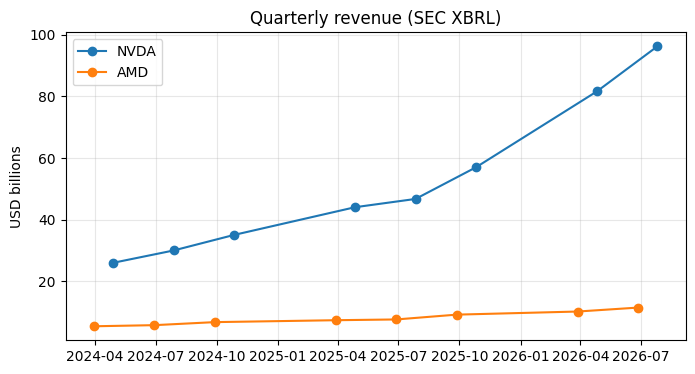

In [19]:
# Optional: quick chart of quarterly revenue from shared memory
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
for t in TICKERS:
    if f"revenue_{vname(t)}" in memory.vars:
        df = memory.get(f"revenue_{vname(t)}")
        plt.plot(pd.to_datetime(df["end"]), df["value"] / 1e9, marker="o", label=t)
plt.title("Quarterly revenue (SEC XBRL)"); plt.ylabel("USD billions"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Step 7 — Proactive monitoring (what makes it an *agent*)
Instead of waiting for questions, the agent checks for new filings. In the real app a scheduler runs this every day; when something new appears it re-runs Steps 4–6 and sends the user an alert.

In [20]:
since = str(dt.date.today() - dt.timedelta(days=60))
for t in TICKERS:
    cik, name = memory.get(f"company_{vname(t)}")["cik"], memory.get(f"company_{vname(t)}")["name"]
    new = recent_filings(cik, since=since)
    print(f"\n{t}: {len(new)} new 10-K/10-Q/8-K filing(s) since {since}")
    for f in new[:5]:
        print(f"  🔔 {f['date']}  {f['form']:5}  {f['url']}")


NVDA: 4 new 10-K/10-Q/8-K filing(s) since 2026-08-03
  🔔 2026-09-03  8-K    https://www.sec.gov/Archives/edgar/data/1045810/000104581026000078/nvda-20260902.htm
  🔔 2026-08-26  10-Q   https://www.sec.gov/Archives/edgar/data/1045810/000104581026000075/nvda-20260726.htm
  🔔 2026-08-26  8-K    https://www.sec.gov/Archives/edgar/data/1045810/000104581026000073/nvda-20260826.htm
  🔔 2026-08-17  8-K    https://www.sec.gov/Archives/edgar/data/1045810/000104581026000069/nvda-20260817.htm

AMD: 5 new 10-K/10-Q/8-K filing(s) since 2026-08-03
  🔔 2026-09-28  8-K    https://www.sec.gov/Archives/edgar/data/2488/000000248826000182/amd-20260926.htm
  🔔 2026-08-19  8-K    https://www.sec.gov/Archives/edgar/data/2488/000000248826000163/amd-20260817.htm
  🔔 2026-08-17  8-K    https://www.sec.gov/Archives/edgar/data/2488/000119312526354029/d142696d8k.htm
  🔔 2026-08-05  10-Q   https://www.sec.gov/Archives/edgar/data/2488/000000248826000123/amd-20260627.htm
  🔔 2026-08-04  8-K    https://www.sec.gov/Arch

## What the agents shared
Everything below lives in **one** memory that every agent could read — no agent had to re-download anything.

In [21]:
print("ACTIVITY LOG:")
print("\n".join("  " + line for line in memory.log))
print(f"\nSOURCES REGISTERED: {len(memory.sources)}")
print("\nMEMORY CONTENTS:\n" + memory.describe())

ACTIVITY LOG:
  [DataCollectionAgent] saved 'company_NVDA'
  [DataCollectionAgent] saved 'revenue_NVDA'
  [DataCollectionAgent] saved 'net_income_NVDA'
  [DataCollectionAgent] saved 'eps_NVDA'
  [DataCollectionAgent] saved 'company_AMD'
  [DataCollectionAgent] saved 'revenue_AMD'
  [DataCollectionAgent] saved 'net_income_AMD'
  [DataCollectionAgent] saved 'eps_AMD'
  [AnalysisAgent] saved 'notes_NVDA'
  [AnalysisAgent] saved 'metrics_NVDA'
  [AnalysisAgent] saved 'notes_AMD'
  [AnalysisAgent] saved 'metrics_AMD'
  [ReportAgent] saved 'final_report'

SOURCES REGISTERED: 10

MEMORY CONTENTS:
- company_NVDA: Basic info for NVDA (by DataCollectionAgent)
- revenue_NVDA: NVDA quarterly revenue (Revenues), 8 quarter(s) (by DataCollectionAgent)
- net_income_NVDA: NVDA quarterly net_income (NetIncomeLoss), 8 quarter(s) (by DataCollectionAgent)
- eps_NVDA: NVDA quarterly eps (EarningsPerShareDiluted), 8 quarter(s) (by DataCollectionAgent)
- company_AMD: Basic info for AMD (by DataCollectionAgent

## From this prototype to the real FinSight (team of 5)
| This notebook | Real system |
|---|---|
| Fixed plan + `input()` approval | LLM planner; user approves/edits the plan in the web UI |
| Pre-written analysis code | LLM writes the code; runs in a sandbox |
| Word-list sentiment | FinBERT; plus NER, summarization, topic modeling, translation, Whisper as tools |
| XBRL numbers only | + 10-K/10-Q text, earnings-call transcripts, news, retrieval with citations to section |
| Template report | LLM two-stage writing + self-check loop |
| Manual Step 7 | Daily scheduler + alerts (email/app) |
| Notebook | FastAPI backend, React/Streamlit UI, deployed on Render/AWS, CI/CD with a coding agent |

Suggested owners: Data Collection Agent · Analysis Agent · Report Agent · Memory + planner/approval · UI + deployment.